# Bank Customer Churn Prediction

## Project Objective

The objective of this project is to build a machine learning model
that can predict whether a bank customer is likely to leave the bank
based on customer demographic and banking information.

This is a binary classification problem where:

- 0 = Customer stays with the bank
- 1 = Customer leaves the bank

In [ ]:
import pandas as pd
df = pd.read_csv('Churn_Modelling.csv')



In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
df.shape

(10000, 14)

In [11]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [13]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [18]:
df = df.drop(columns = ['RowNumber', 'CustomerId', 'Surname'])

In [19]:
df.shape

(10000, 11)

In [20]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [21]:
df['Exited'].value_counts(normalize=True) * 100

,proportion
Exited,
0,79.63
1,20.37


In [22]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [24]:
Zero_Bal_cust = (df['Balance'] == 0).sum()
print(Zero_Bal_cust)
total_Num_cust = len(df)
print(total_Num_cust)
PercentageValue = (Zero_Bal_cust/total_Num_cust) * 100
print(PercentageValue)

3617
10000
36.17


In [39]:
df[df['Balance'] == 0]['Exited'].value_counts()
Churn_zero_bal_cust = df[df['Balance'] == 0]['Exited'].value_counts(normalize = True) * 100
print(Churn_zero_bal_cust)





Exited
0    86.176389
1    13.823611
Name: proportion, dtype: float64


Note for future -
Initially i wanted to seperate the exited value 0 and 1.For that code is
df[(df['Balance'] != 0) & (df['Exited'] == 1)]
Balance != 0   → balance zero nahi hona chahiye
       AND
Exited == 1    → customer churned hona chahiye

also for count
df[(df['Balance'] != 0) & (df['Exited'] == 1)].shape[0]


In [38]:
df[df['Balance'] != 0]['Exited'].value_counts()

Churn_non_zero_bal_cust = df[df['Balance']!= 0]['Exited'].value_counts(normalize = True) * 100
print(Churn_non_zero_bal_cust)


Exited
0    75.920414
1    24.079586
Name: proportion, dtype: float64


In [40]:
df.groupby('Exited')['Age'].mean()

,Age
Exited,
0,37.408389
1,44.837997


In [41]:
df.groupby('Exited')[
    ['CreditScore', 'Age', 'Tenure', 'Balance',
     'NumOfProducts', 'EstimatedSalary']
].mean()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
Exited,,,,,,
0,651.853196,37.408389,5.033279,72745.296779,1.544267,99738.391772
1,645.351497,44.837997,4.932744,91108.539337,1.475209,101465.677531


In [42]:
df.groupby('Geography')['Exited'].mean() * 100

,Exited
Geography,
France,16.154767
Germany,32.443204
Spain,16.673395


In [43]:
print("Gender:")
print(df.groupby('Gender')['Exited'].mean() * 100)

print("\nNumber of Products:")
print(df.groupby('NumOfProducts')['Exited'].mean() * 100)

print("\nCredit Card:")
print(df.groupby('HasCrCard')['Exited'].mean() * 100)

print("\nActive Member:")
print(df.groupby('IsActiveMember')['Exited'].mean() * 100)

Gender:
Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

Number of Products:
NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64

Credit Card:
HasCrCard
0    20.814941
1    20.184266
Name: Exited, dtype: float64

Active Member:
IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64


In [44]:
df.groupby('NumOfProducts')['Exited'].agg(['count', 'sum', 'mean'])

,count,sum,mean
NumOfProducts,,,
1,5084,1409,0.277144
2,4590,348,0.075817
3,266,220,0.827068
4,60,60,1.000000


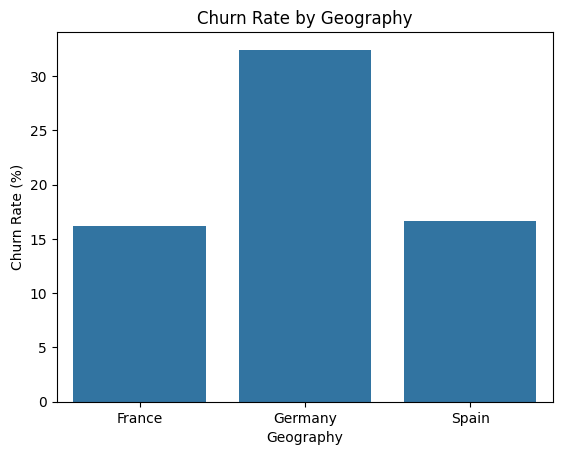

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

geo_churn = df.groupby('Geography')['Exited'].mean() * 100

sns.barplot(x=geo_churn.index, y=geo_churn.values)

plt.title('Churn Rate by Geography')
plt.xlabel('Geography')
plt.ylabel('Churn Rate (%)')
plt.show()